# Prophet Forecasting – Waste by Canteen Section

This notebook builds separate Prophet models for sections **A, B, C, D**.
For each section:
- Hyperparameter tuning via time‑series cross‑validation
- Compare tuned model against a baseline (default Prophet)
- Save the best model as a pickle file
- Finally, show a sample usage of loading a model and forecasting future waste

In [43]:
import os
import pickle
import itertools
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

os.makedirs("models/prophet", exist_ok=True)

## 1. Load and Prepare Data

The dataset `waste_features_full.csv` contains daily waste (kg), foot traffic, holiday flags, and special event flags for each section.

In [44]:
df = pd.read_csv("data/waste_features_full.csv", parse_dates=["date"])
print(f"Full dataset shape: {df.shape}")
print(df.head())

Full dataset shape: (724, 21)
        date section  waste_kg  foot_traffic  waste_organic_kg  \
0 2025-01-01       a     23.64      8.307692             13.89   
1 2025-01-01       b     23.08      9.357143             11.63   
2 2025-01-01       c      7.59      6.250000              3.75   
3 2025-01-01       d     15.09      7.461538              7.86   
4 2025-01-02       a      5.12      6.000000              2.88   

   waste_recyclable_kg  waste_landfill_kg  is_holiday  has_special_event  \
0                 6.70               3.07           1                  1   
1                 6.85               4.17           1                  1   
2                 2.28               1.56           1                  1   
3                 4.61               2.63           1                  1   
4                 1.47               0.76           0                  1   

   year  ...  day  day_of_week  day_of_year  week_of_year  quarter  \
0  2025  ...    1            2            1   

## 2. Helper Functions

- `prepare_section_data()`: filter section, rename columns to Prophet format (`ds`, `y`), and split into train/test (last 30 days as test).
- `cross_validate_params()`: perform grid search over Prophet hyperparameters using time‑series cross‑validation.
- `train_and_evaluate()`: train a model (baseline or tuned) and evaluate on test set.
- `plot_forecast()`: visualise actual vs forecast with uncertainty intervals.

In [45]:
def prepare_section_data(df, section, test_days=30):
    """Filter section, rename columns, split into train/test."""
    sec_df = (
        df[df["section"] == section]
        [["date", "waste_kg", "foot_traffic", "is_holiday", "has_special_event"]]
        .rename(columns={"date": "ds", "waste_kg": "y"})
        .copy()
    )
    cutoff = sec_df["ds"].max() - pd.DateOffset(days=test_days)
    train = sec_df[sec_df["ds"] <= cutoff].reset_index(drop=True)
    test  = sec_df[sec_df["ds"] >  cutoff].reset_index(drop=True)
    return sec_df, train, test

def cross_validate_params(train, param_grid, cv_initial="90 days", cv_period="7 days", cv_horizon="14 days"):
    """Grid search with Prophet's cross_validation. Returns best params dict."""
    all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
    results = []
    for params in all_params:
        m = Prophet(
            weekly_seasonality=True,
            yearly_seasonality=True,
            daily_seasonality=False,
            **params
        )
        m.add_regressor("foot_traffic")
        m.add_regressor("is_holiday")
        m.add_regressor("has_special_event")
        m.fit(train)
        df_cv = cross_validation(m, initial=cv_initial, period=cv_period, horizon=cv_horizon, disable_tqdm=True)
        df_pm = performance_metrics(df_cv, rolling_window=1)
        results.append({
            **params,
            "cv_rmse": df_pm["rmse"].mean(),
            "cv_mae": df_pm["mae"].mean()
        })
    best = pd.DataFrame(results).sort_values(["cv_rmse", "cv_mae"]).iloc[0]
    return best[["changepoint_prior_scale", "seasonality_prior_scale", "seasonality_mode"]].to_dict()

def train_and_evaluate(train, test, params=None):
    """Train a Prophet model (baseline if params=None, else tuned) and evaluate on test."""
    if params is None:
        m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
    else:
        m = Prophet(
            weekly_seasonality=True,
            yearly_seasonality=True,
            daily_seasonality=False,
            changepoint_prior_scale=params["changepoint_prior_scale"],
            seasonality_prior_scale=params["seasonality_prior_scale"],
            seasonality_mode=params["seasonality_mode"]
        )
    m.add_regressor("foot_traffic")
    m.add_regressor("is_holiday")
    m.add_regressor("has_special_event")
    m.fit(train)

    future = test[["ds", "foot_traffic", "is_holiday", "has_special_event"]].copy()
    fcst = m.predict(future)
    y_true = test["y"].values
    y_pred = fcst["yhat"].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return m, {"rmse": rmse, "mae": mae, "mape": mape}

def plot_forecast(test, fcst, title, ax):
    """Plot actual vs forecast with uncertainty interval."""
    ax.plot(test["ds"], test["y"], label="Actual", marker="o", markersize=3, color="black")
    ax.plot(fcst["ds"], fcst["yhat"], label="Forecast", linestyle="--", color="blue")
    ax.fill_between(fcst["ds"], fcst["yhat_lower"], fcst["yhat_upper"], alpha=0.2, color="blue", label="95% CI")
    ax.set_title(title)
    ax.set_ylabel("Waste (kg)")
    ax.legend()

print("Helper functions defined.")

Helper functions defined.


## 3. Train & Tune Models for All Sections (A, B, C, D)

For each section:
- Split data (last 30 days = test set)
- Find best hyperparameters via cross‑validation (grid search)
- Train baseline (default) and tuned models, evaluate on test
- Save tuned model as pickle
- Store metrics for comparison

18:51:30 - cmdstanpy - INFO - Chain [1] start processing
18:51:30 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
18:51:30 - cmdstanpy - INFO - Chain [1] start processing
18:51:30 - cmdstanpy - INFO - Chain [1] done processing



Processing Section A
Train size: 151, Test size: 30


18:51:30 - cmdstanpy - INFO - Chain [1] start processing
18:51:30 - cmdstanpy - INFO - Chain [1] done processing
18:51:30 - cmdstanpy - INFO - Chain [1] start processing
18:51:30 - cmdstanpy - INFO - Chain [1] done processing
18:51:30 - cmdstanpy - INFO - Chain [1] start processing
18:51:30 - cmdstanpy - INFO - Chain [1] done processing
18:51:30 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
18:51:30 - cmdstanpy - INFO - Chain [1] start processing
18:51:30 - cmdstanpy - INFO - Chain [1] done processing
18:51:30 - cmdstanpy - INFO - Chain [1] start processing
18:51:30 - cmdstanpy - INFO - Chain [1] done processing
18:51:30 - cmdstanpy - INFO - Chain [1] start processing
18:51:30 - cmdstanpy - INFO - Chain [1] done processing
18:51:30 - cmdstanpy - INFO - Chain [1] start processing
18:51:30 - cmdstanpy - INFO - Chain [1] done processing
18:51:30 - cmdstanpy - INFO - Chain [1] start processing
18:51:30 - 

Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'additive'}
Saved tuned model to models/prophet/prophet_section_a.pkl


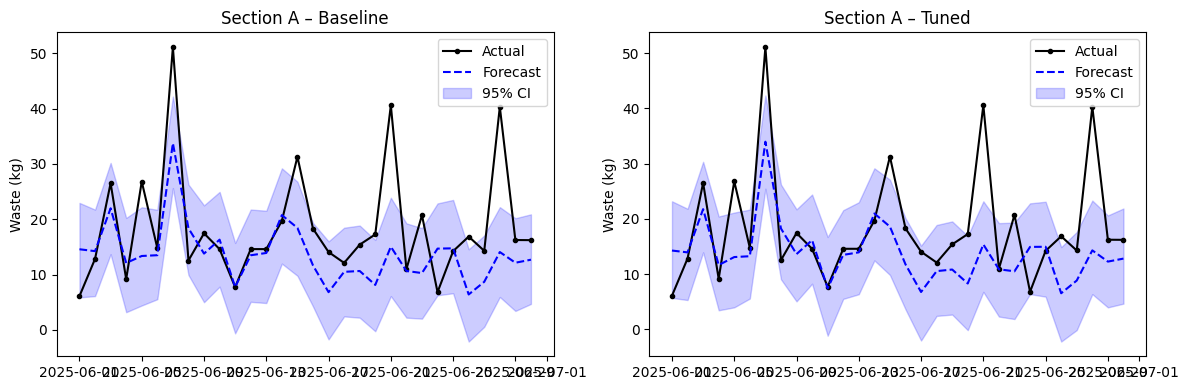

18:51:54 - cmdstanpy - INFO - Chain [1] start processing



Processing Section B
Train size: 151, Test size: 30


18:51:54 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
18:51:54 - cmdstanpy - INFO - Chain [1] start processing
18:51:54 - cmdstanpy - INFO - Chain [1] done processing
18:51:54 - cmdstanpy - INFO - Chain [1] start processing
18:51:54 - cmdstanpy - INFO - Chain [1] done processing
18:51:54 - cmdstanpy - INFO - Chain [1] start processing
18:51:54 - cmdstanpy - INFO - Chain [1] done processing
18:51:54 - cmdstanpy - INFO - Chain [1] start processing
18:51:54 - cmdstanpy - INFO - Chain [1] done processing
18:51:54 - cmdstanpy - INFO - Chain [1] start processing
18:51:54 - cmdstanpy - INFO - Chain [1] done processing
18:51:54 - cmdstanpy - INFO - Chain [1] start processing
18:51:54 - cmdstanpy - INFO - Chain [1] done processing
18:51:54 - cmdstanpy - INFO - Chain [1] start processing
18:51:54 - cmdstanpy - INFO - Chain [1] done processing
18:51:54 - cmdstanpy - INFO - Chain [1] start pro

Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'additive'}
Saved tuned model to models/prophet/prophet_section_b.pkl


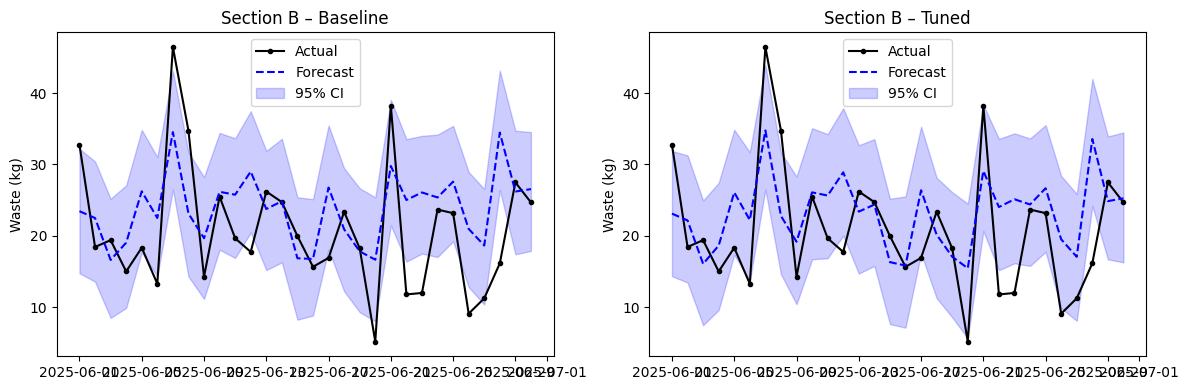


Processing Section C
Train size: 151, Test size: 30


18:52:06 - cmdstanpy - INFO - Chain [1] start processing
18:52:06 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
18:52:06 - cmdstanpy - INFO - Chain [1] start processing
18:52:06 - cmdstanpy - INFO - Chain [1] done processing
18:52:06 - cmdstanpy - INFO - Chain [1] start processing
18:52:06 - cmdstanpy - INFO - Chain [1] done processing
18:52:06 - cmdstanpy - INFO - Chain [1] start processing
18:52:06 - cmdstanpy - INFO - Chain [1] done processing
18:52:06 - cmdstanpy - INFO - Chain [1] start processing
18:52:06 - cmdstanpy - INFO - Chain [1] done processing
18:52:06 - cmdstanpy - INFO - Chain [1] start processing
18:52:06 - cmdstanpy - INFO - Chain [1] done processing
18:52:06 - cmdstanpy - INFO - Chain [1] start processing
18:52:06 - cmdstanpy - INFO - Chain [1] done processing
18:52:06 - cmdstanpy - INFO - Chain [1] start processing
18:52:06 - cmdstanpy - INFO - Chain [1] done pro

Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'additive'}
Saved tuned model to models/prophet/prophet_section_c.pkl


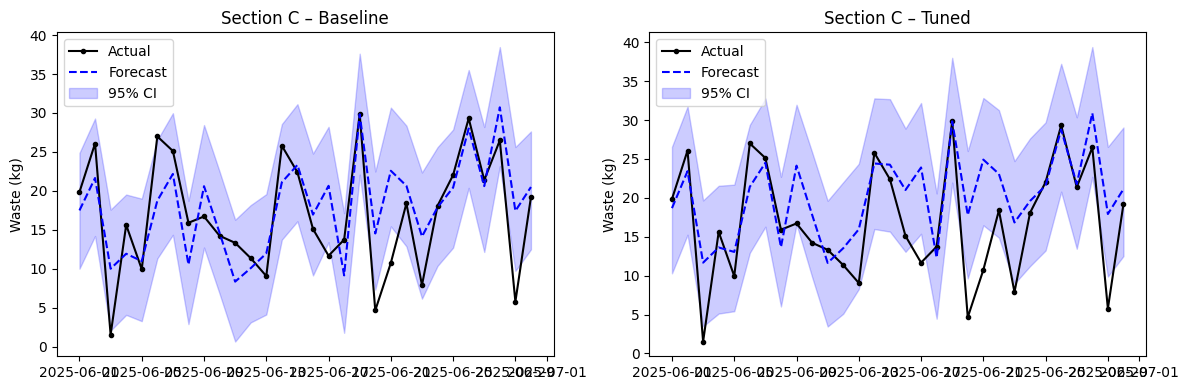


Processing Section D
Train size: 151, Test size: 30


18:52:16 - cmdstanpy - INFO - Chain [1] start processing
18:52:16 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
18:52:16 - cmdstanpy - INFO - Chain [1] start processing
18:52:16 - cmdstanpy - INFO - Chain [1] done processing
18:52:16 - cmdstanpy - INFO - Chain [1] start processing
18:52:16 - cmdstanpy - INFO - Chain [1] done processing
18:52:16 - cmdstanpy - INFO - Chain [1] start processing
18:52:16 - cmdstanpy - INFO - Chain [1] done processing
18:52:16 - cmdstanpy - INFO - Chain [1] start processing
18:52:16 - cmdstanpy - INFO - Chain [1] done processing
18:52:16 - cmdstanpy - INFO - Chain [1] start processing
18:52:16 - cmdstanpy - INFO - Chain [1] done processing
18:52:16 - cmdstanpy - INFO - Chain [1] start processing
18:52:16 - cmdstanpy - INFO - Chain [1] done processing
18:52:16 - cmdstanpy - INFO - Chain [1] start processing
18:52:16 - cmdstanpy - INFO - Chain [1] done pro

Best params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'additive'}
Saved tuned model to models/prophet/prophet_section_d.pkl


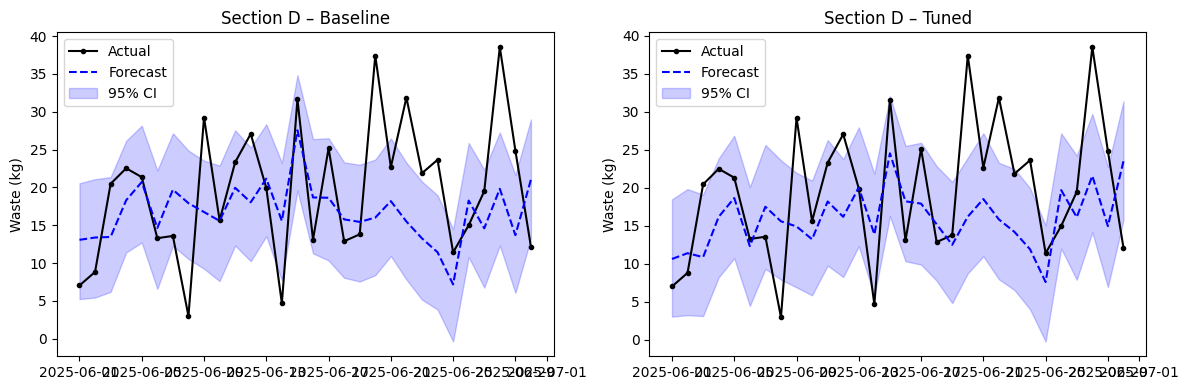


All sections processed.


In [46]:
# Hyperparameter grid
param_grid = {
    "changepoint_prior_scale": [0.01, 0.1, 0.5],
    "seasonality_prior_scale": [0.1, 1.0, 10.0],
    "seasonality_mode": ["additive", "multiplicative"]
}

sections = ["a", "b", "c", "d"]
results = []   # will store metrics for each section

for section in sections:
    print(f"\n{'='*50}")
    print(f"Processing Section {section.upper()}")
    print('='*50)

    # Prepare data
    _, train, test = prepare_section_data(df, section, test_days=30)
    print(f"Train size: {len(train)}, Test size: {len(test)}")

    # Cross‑validation tuning
    best_params = cross_validate_params(train, param_grid)
    print(f"Best params: {best_params}")

    # Baseline model (default)
    baseline_model, baseline_metrics = train_and_evaluate(train, test, params=None)

    # Tuned model
    tuned_model, tuned_metrics = train_and_evaluate(train, test, params=best_params)

    # Save tuned model
    model_path = f"models/prophet/prophet_section_{section}.pkl"
    with open(model_path, "wb") as f:
        pickle.dump(tuned_model, f)
    print(f"Saved tuned model to {model_path}")

    # Store metrics
    results.append({
        "section": section.upper(),
        "baseline_rmse": baseline_metrics["rmse"],
        "tuned_rmse": tuned_metrics["rmse"],
        "baseline_mae": baseline_metrics["mae"],
        "tuned_mae": tuned_metrics["mae"],
        "baseline_mape": baseline_metrics["mape"],
        "tuned_mape": tuned_metrics["mape"]
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    future_test = test[["ds", "foot_traffic", "is_holiday", "has_special_event"]].copy()
    fcst_base = baseline_model.predict(future_test)
    fcst_tuned = tuned_model.predict(future_test)
    plot_forecast(test, fcst_base, f"Section {section.upper()} – Baseline", axes[0])
    plot_forecast(test, fcst_tuned, f"Section {section.upper()} – Tuned", axes[1])
    plt.tight_layout()
    plt.show()

print("\nAll sections processed.")

## 4. Performance Comparison: Baseline vs Tuned

We summarise RMSE, MAE and MAPE for each section and compute the percentage improvement achieved by tuning.


=== Model Performance Summary ===
section  baseline_rmse  tuned_rmse  baseline_mae  tuned_mae  baseline_mape  tuned_mape  rmse_improvement_%  mae_improvement_%
      A           9.47        9.37          6.68       6.61          35.43       35.01                1.06               1.06
      B           8.16        7.82          6.59       6.33          44.07       41.22                4.23               3.99
      C           5.28        6.13          4.08       4.48          53.31       63.70              -15.98              -9.88
      D           9.01        8.93          7.23       7.27          55.48       51.25                0.94              -0.51


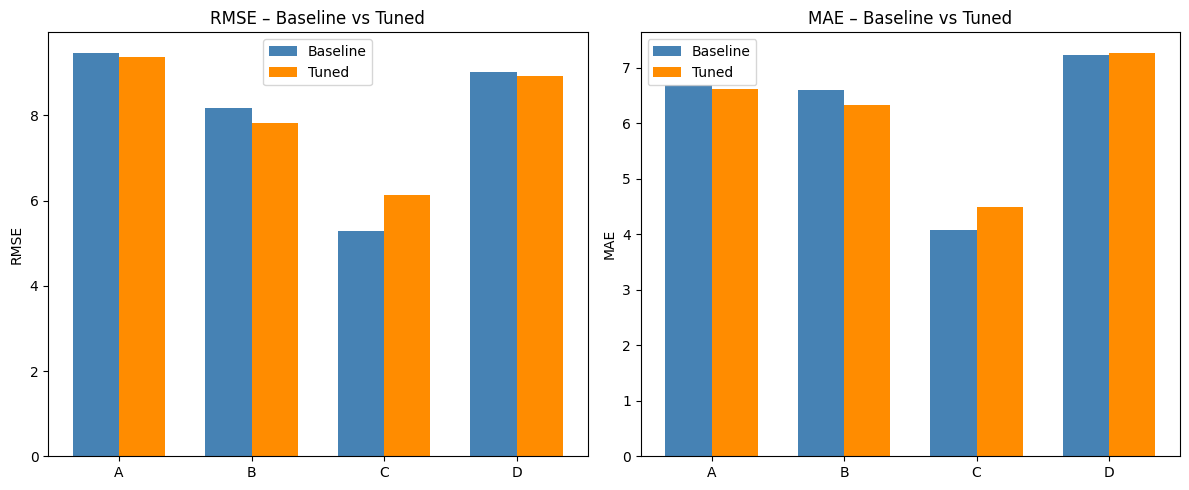


Improvement from tuning (positive = better):
section  rmse_improvement_%  mae_improvement_%
      A                1.06               1.06
      B                4.23               3.99
      C              -15.98              -9.88
      D                0.94              -0.51


In [47]:
results_df = pd.DataFrame(results)

# Compute improvement (%)
results_df["rmse_improvement_%"] = (results_df["baseline_rmse"] - results_df["tuned_rmse"]) / results_df["baseline_rmse"] * 100
results_df["mae_improvement_%"]  = (results_df["baseline_mae"] - results_df["tuned_mae"]) / results_df["baseline_mae"] * 100

print("\n=== Model Performance Summary ===")
print(results_df.round(2).to_string(index=False))

# Bar plot comparison
metrics = ["RMSE", "MAE"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, metric in enumerate(metrics):
    baseline_col = f"baseline_{metric.lower()}"
    tuned_col = f"tuned_{metric.lower()}"
    x = np.arange(len(sections))
    width = 0.35
    axes[idx].bar(x - width/2, results_df[baseline_col], width, label="Baseline", color="steelblue")
    axes[idx].bar(x + width/2, results_df[tuned_col], width, label="Tuned", color="darkorange")
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(results_df["section"])
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(f"{metric} – Baseline vs Tuned")
    axes[idx].legend()

plt.tight_layout()
plt.show()

print("\nImprovement from tuning (positive = better):")
print(results_df[["section", "rmse_improvement_%", "mae_improvement_%"]].round(2).to_string(index=False))

## 5. Usage: Load a Saved Model and Forecast Future Waste

Here we demonstrate how to load one of the saved Prophet models and generate a forecast for the next 14 days, using **assumed future values** of the regressors (foot traffic, holidays, events).

Loaded model for section A

Forecast for next 14 days (kg of waste):
        ds   yhat  yhat_lower  yhat_upper
2025-07-01 451.88      443.42      459.73
2025-07-02 451.58      443.49      460.03
2025-07-03 447.60      438.99      456.40
2025-07-04 451.56      442.99      460.34
2025-07-05 453.76      445.44      462.70
2025-07-06 452.94      444.80      461.25
2025-07-07 451.78      443.05      459.86
2025-07-08 452.04      443.59      460.87
2025-07-09 451.65      443.15      460.50
2025-07-10 447.55      439.53      456.48
2025-07-11 451.40      443.03      459.99
2025-07-12 453.48      444.75      462.18
2025-07-13 452.54      444.24      460.28
2025-07-14 451.26      442.28      459.89


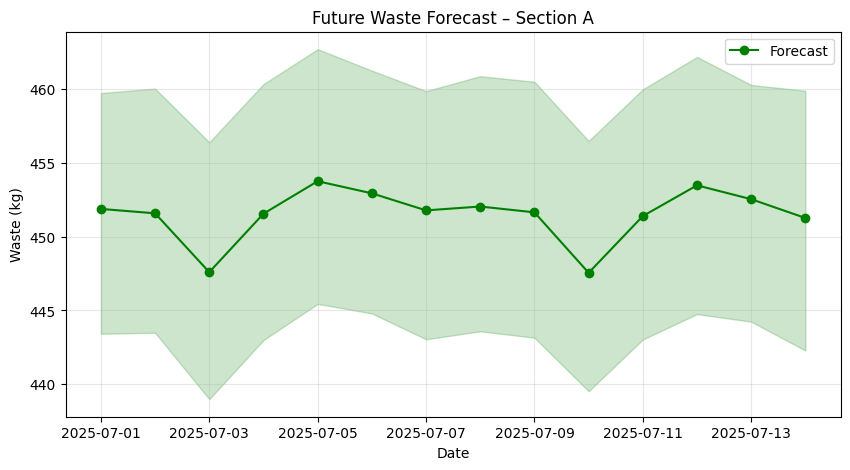

In [48]:
model_path = f"models/prophet/prophet_section_a.pkl"

with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)

print(f"Loaded model for section A")


future_dates = pd.date_range(start=df["date"].max() + pd.Timedelta(days=1), periods=14, freq="D")

future_df = pd.DataFrame({
    "ds": future_dates,
    "foot_traffic": 500,
    "is_holiday": 0,
    "has_special_event": 0
})

forecast = loaded_model.predict(future_df)

print("\nForecast for next 14 days (kg of waste):")
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].round(2).to_string(index=False))

plt.figure(figsize=(10, 5))
plt.plot(forecast["ds"], forecast["yhat"], label="Forecast", marker="o", color="green")
plt.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"], alpha=0.2, color="green")
plt.title(f"Future Waste Forecast – Section A")
plt.xlabel("Date")
plt.ylabel("Waste (kg)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()